# Cropland Field Parcels From January-June Landsat

This notebook builds a cropland and field-parcel candidate layer for our AOI using the workflow from Graesser and Ramankutty, *Detection of cropland field parcels from Landsat imagery*, Remote Sensing of Environment 201 (2017), DOI `10.1016/j.rse.2017.08.027`.

The important idea from the paper is that field parcels are not produced from a simple NDVI threshold. The workflow first prepares cloud-free Landsat surface reflectance, derives spectral and temporal variables from multiple dates, smooths those variables while preserving field edges, extracts field-like objects from image edges, estimates cropland pixels, and then labels each object as cropland when enough of its pixels behave like cropland.

For this project, the expected input is the January-June 2026 STAC workflow from notebook `1.1_download_raster_img.ipynb`: individual AOI-clipped Landsat scene bands in `data/raw/landsat/stac_aoi_clips/202601_202606` and AOI-wide cloud-masked mosaics in `data/processed/landsat/mosaics/202601_202606`.


## Paper Methodology Translated To This Notebook

The paper workflow is adapted here as the following steps:

1. **Prepare January-June AOI Landsat inputs**: use cloud-masked Landsat Collection 2 surface reflectance clips and AOI mosaics from January-June 2026. The scene clips preserve individual dates for temporal statistics, while the mosaics provide a common AOI grid and visualization base.
2. **Scale reflectance bands**: convert Landsat integer DN values to surface reflectance with the Collection 2 scale and offset. This makes the spectral indices physically meaningful and comparable between scenes.
3. **Compute spectral transformations per date**: derive the paper-style Landsat variables for every complete scene: `NDVI`, `EVI2`, `GNDVI`, `NDSI`, and `NDBaI`.
4. **Build time-series variables**: summarize January-June index stacks using the temporal features consumed downstream: median index values, NDVI min/max, and NDVI seasonal range. This is the part that makes the workflow multi-date instead of a single-image threshold.
5. **Smooth with a bilateral filter**: apply edge-preserving bilateral smoothing before gradient extraction. This reduces within-field noise while keeping strong field boundaries sharper than a simple mean or median filter would.
6. **Extract edges and objects**: calculate gradients on the smoothed variables, threshold local contrast, clean the edge layer, and invert it to create contiguous field-like objects. This follows the paper's object-based logic: field boundaries should appear as repeated spectral edges.
7. **Estimate cropland pixels**: create an initial cropland candidate mask from temporal vegetation and soil/moisture behavior. This is a practical placeholder for the paper's supervised cropland classifier until we prepare training samples.
8. **Label field parcels**: summarize cropland pixels inside each extracted object and label an object as cropland when at least half of its valid pixels are cropland, matching the paper's object-labeling rule.
9. **Export raster and vector outputs**: write pixel-level cropland candidates, object labels, and cropland parcel polygons for inspection and later MRV analysis.
10. **Validate and improve**: compare outputs against field knowledge, high-resolution imagery, or existing land-cover products. The current output should be treated as a candidate layer, not a final validated cropland map.


In [1]:
from pathlib import Path
import os
import gc
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.features import shapes
from rasterio.warp import Resampling, reproject
from scipy import ndimage
from shapely.geometry import shape
from skimage.restoration import denoise_bilateral

def mount_google_drive_if_colab() -> None:
    try:
        from google.colab import drive
    except ModuleNotFoundError:
        return

    drive.mount("/content/drive")


mount_google_drive_if_colab()

COLAB_PROJECT_ROOT = Path("/content/drive/MyDrive/erw_spatial_mrv")
COLAB_DATA_ROOT = COLAB_PROJECT_ROOT / "data"
LOCAL_PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()


def has_erw_package(project_root: Path) -> bool:
    return (project_root / "src" / "erw_mrv" / "__init__.py").exists()


def source_root_candidates() -> list[Path]:
    cwd = Path.cwd().resolve()
    candidates = [LOCAL_PROJECT_ROOT, COLAB_PROJECT_ROOT]
    for base in (cwd, *cwd.parents):
        candidates.extend((base, base / "erw_spatial_mrv"))
    candidates.extend(
        Path(path)
        for path in (
            "/content/erw_spatial_mrv",
            "/content/enhanced_rock_weathering/erw_spatial_mrv",
            "/content/drive/MyDrive/erw_spatial_mrv",
        )
    )
    unique = []
    for candidate in candidates:
        if candidate not in unique:
            unique.append(candidate)
    return unique


def find_source_project_root() -> Path:
    for candidate in source_root_candidates():
        if has_erw_package(candidate):
            return candidate
    checked = chr(10).join(f"- {candidate}" for candidate in source_root_candidates())
    raise ModuleNotFoundError(
        "Could not find src/erw_mrv. The data can live in Google Drive, but "
        "the notebook still needs the project source folder containing src/erw_mrv. "
        "In Colab, upload/sync the full erw_spatial_mrv project or run from a "
        "checkout that includes src/. Checked: "
        f"{checked}"
    )


SOURCE_PROJECT_ROOT = find_source_project_root()
PROJECT_ROOT = COLAB_PROJECT_ROOT if COLAB_DATA_ROOT.exists() else SOURCE_PROJECT_ROOT
DATA_ROOT = COLAB_DATA_ROOT if COLAB_DATA_ROOT.exists() else PROJECT_ROOT / "data"
os.environ["ERW_MRV_DATA_ROOT"] = str(DATA_ROOT)

SRC = SOURCE_PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"SOURCE_PROJECT_ROOT = {SOURCE_PROJECT_ROOT}")
print(f"DATA_ROOT = {DATA_ROOT}")


plt.rcParams["figure.figsize"] = (10, 8)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT = /content/drive/MyDrive/erw_spatial_mrv
SOURCE_PROJECT_ROOT = /content/drive/MyDrive/erw_spatial_mrv
DATA_ROOT = /content/drive/MyDrive/erw_spatial_mrv/data


## Prepare January-June Landsat Inputs

This notebook expects notebook `1.1_download_raster_img.ipynb` to have produced two kinds of files:

- individual scene clips in `data/raw/landsat/stac_aoi_clips/202601_202606`, named like `{scene_id}_{band}_aoi.tif`
- final AOI mosaics in `data/processed/landsat/mosaics/202601_202606`, named like `landsat_{band}_mosaic_aoi.tif`

The mosaics define the common AOI grid. The individual scene clips are reprojected to that grid so we can compute January-June temporal statistics per pixel.


In [2]:
LANDCOVER_DIR = PROJECT_ROOT / "data" / "processed" / "landcover"
LANDCOVER_DIR.mkdir(parents=True, exist_ok=True)

DATE_TAG = "202601_202606"
OUTPUT_TAG = "jan_jun_2026"
CLIP_DIR = PROJECT_ROOT / "data" / "raw" / "landsat" / "stac_aoi_clips" / DATE_TAG
MOSAIC_DIR = PROJECT_ROOT / "data" / "processed" / "landsat" / "mosaics" / DATE_TAG
MOSAIC_PATTERN = "landsat_{band}_mosaic_aoi.tif"
REQUIRED_BANDS = ("blue", "green", "red", "nir08", "swir16", "swir22")

missing_mosaics = [band for band in REQUIRED_BANDS if not (MOSAIC_DIR / MOSAIC_PATTERN.format(band=band)).exists()]
if missing_mosaics:
    raise FileNotFoundError(
        "Missing January-June mosaic band(s): "
        + ", ".join(missing_mosaics)
        + ". Finish the download and mosaic steps in notebook 1.1 before running this cropland workflow."
    )

if not CLIP_DIR.exists():
    raise FileNotFoundError(f"Missing scene clip directory: {CLIP_DIR}")

print(f"Using January-June mosaics: {MOSAIC_DIR}")
print(f"Using January-June scene clips: {CLIP_DIR}")


Using January-June mosaics: /content/drive/MyDrive/erw_spatial_mrv/data/processed/landsat/mosaics/202601_202606
Using January-June scene clips: /content/drive/MyDrive/erw_spatial_mrv/data/raw/landsat/stac_aoi_clips/202601_202606


## Load And Scale Surface Reflectance

Landsat Collection 2 surface reflectance bands are stored as scaled integers. We convert them to reflectance using:

`reflectance = DN * 0.0000275 - 0.2`

NoData/cloud-masked pixels remain `NaN`.

In [3]:
SCALE = 0.0000275
OFFSET = -0.2
SENTINEL = -9999.0


def band_path(band):
    return MOSAIC_DIR / MOSAIC_PATTERN.format(band=band)


def scale_landsat_reflectance(raw, nodata=None):
    raw = raw.astype("float32")
    invalid = raw <= 0
    if nodata is not None:
        invalid |= raw == nodata
    data = raw * SCALE + OFFSET
    data[invalid] = np.nan
    return data.astype("float32")


def read_reflectance_band(band):
    path = band_path(band)
    with rasterio.open(path) as src:
        raw = src.read(1)
        profile = src.profile.copy()
        nodata = src.nodata
    return scale_landsat_reflectance(raw, nodata), profile


blue, profile = read_reflectance_band("blue")
green, _ = read_reflectance_band("green")
red, _ = read_reflectance_band("red")
nir, _ = read_reflectance_band("nir08")
swir1, _ = read_reflectance_band("swir16")
swir2, _ = read_reflectance_band("swir22")

valid = np.isfinite(red) & np.isfinite(green) & np.isfinite(nir) & np.isfinite(swir1) & np.isfinite(swir2)
print(f"Valid cloud-free mosaic pixels: {valid.sum():,}")


Valid cloud-free mosaic pixels: 19,326,858


## Visual Check

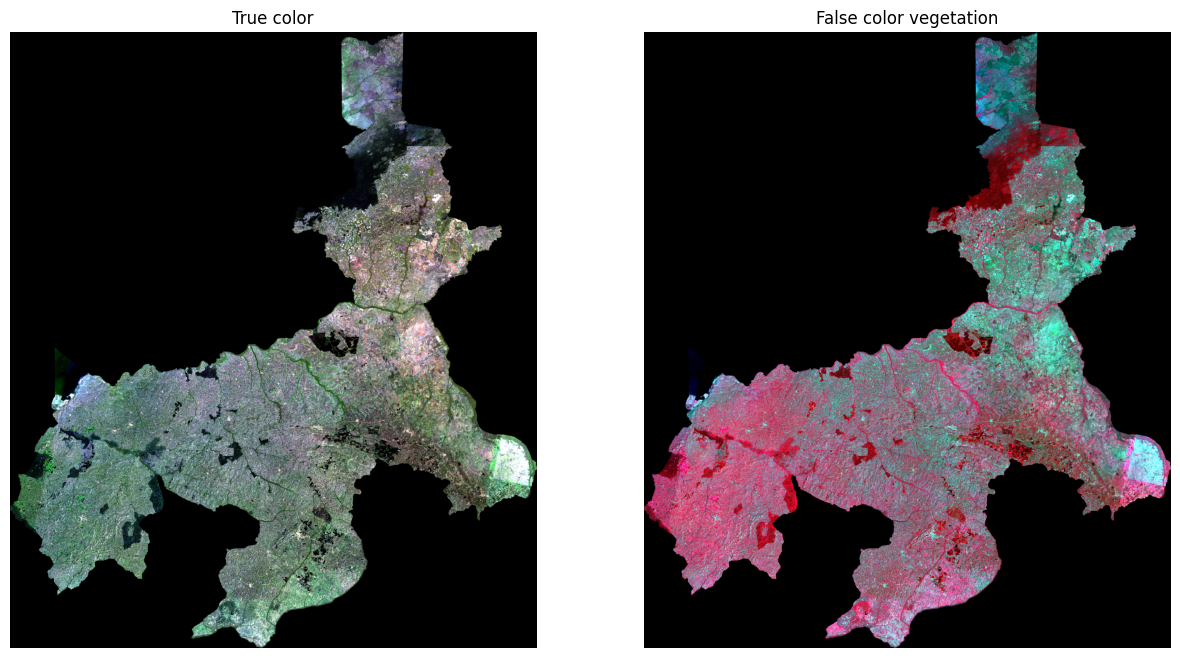

In [4]:
def stretch(values, lower=2, upper=98):
    lo, hi = np.nanpercentile(values, [lower, upper])
    if hi <= lo:
        return np.zeros_like(values, dtype="float32")
    return np.clip((values - lo) / (hi - lo), 0, 1)

rgb = np.dstack([stretch(red), stretch(green), stretch(blue)])
false_color = np.dstack([stretch(nir), stretch(red), stretch(green)])

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
axes[0].imshow(np.nan_to_num(rgb, nan=0))
axes[0].set_title("True color")
axes[0].set_axis_off()
axes[1].imshow(np.nan_to_num(false_color, nan=0))
axes[1].set_title("False color vegetation")
axes[1].set_axis_off()
plt.show()


## Spectral Transformations From The Paper

The paper computes five spectral transformations from Landsat time series:

- `NDVI = (NIR - red) / (NIR + red)`
- `EVI2 = 2.5 * (NIR - red) / (NIR + 2.4 * red + 1)`
- `GNDVI = (NIR - green) / (NIR + green)`
- `NDSI = (MidIR - NIR) / (MidIR + NIR)`
- `NDBaI = (FarIR - NIR) / (FarIR + NIR)`

With Landsat 8/9, `MidIR` is approximated here with `swir16`, and `FarIR` with `swir22`.

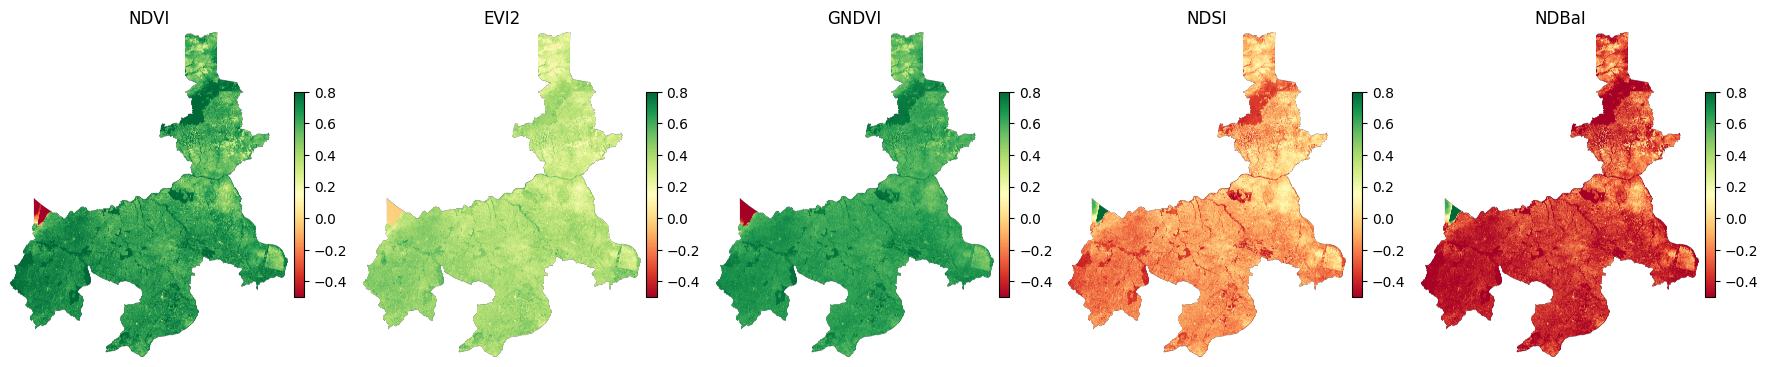

In [5]:
def normalized_difference(a, b):
    denominator = a + b
    out = np.full(a.shape, np.nan, dtype="float32")
    np.divide(a - b, denominator, out=out, where=np.isfinite(denominator) & (denominator != 0))
    return out

ndvi = normalized_difference(nir, red)
evi2 = np.full(nir.shape, np.nan, dtype="float32")
evi2_denominator = nir + 2.4 * red + 1
np.divide(2.5 * (nir - red), evi2_denominator, out=evi2, where=np.isfinite(evi2_denominator) & (evi2_denominator != 0))
gndvi = normalized_difference(nir, green)
ndsi = normalized_difference(swir1, nir)
ndbai = normalized_difference(swir2, nir)

indices = {
    "NDVI": ndvi,
    "EVI2": evi2,
    "GNDVI": gndvi,
    "NDSI": ndsi,
    "NDBaI": ndbai,
}

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, (name, values) in zip(axes, indices.items()):
    im = ax.imshow(values, cmap="RdYlGn", vmin=-0.5, vmax=0.8)
    ax.set_title(name)
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
plt.show()


## Paper Step: January-June Time-Series Variables

The paper computes annual or growing-season statistics from many Landsat observations. Here we use every complete January-June 2026 AOI-clipped scene in `CLIP_DIR`, align each scene to the mosaic grid, compute the five spectral transformations per scene, and then summarize each index through time.

This gives us the multi-date signal we need for cropland: persistent or recurring greenness, seasonal range, variability, and soil/moisture behavior. Clouded or missing pixels remain `NaN`; each statistic is computed from the available clear observations at that pixel.


In [6]:
def scene_id_from_band_path(path, band):
    suffix = f"_{band}_aoi"
    stem = path.stem
    if not stem.endswith(suffix):
        return None
    return stem[: -len(suffix)]


def scene_band_path(scene_id, band):
    return CLIP_DIR / f"{scene_id}_{band}_aoi.tif"


def discover_complete_scene_ids(required_bands=REQUIRED_BANDS):
    scene_ids = set()
    for path in CLIP_DIR.glob("*_blue_aoi.tif"):
        scene_id = scene_id_from_band_path(path, "blue")
        if scene_id:
            scene_ids.add(scene_id)
    complete = []
    incomplete = {}
    for scene_id in sorted(scene_ids):
        missing = [band for band in required_bands if not scene_band_path(scene_id, band).exists()]
        if missing:
            incomplete[scene_id] = missing
        else:
            complete.append(scene_id)
    return complete, incomplete


def read_scene_reflectance_on_grid(scene_id, band, reference_profile):
    path = scene_band_path(scene_id, band)
    height = reference_profile["height"]
    width = reference_profile["width"]
    destination = np.full((height, width), SENTINEL, dtype="float32")

    with rasterio.open(path) as src:
        raw = src.read(1)
        source = scale_landsat_reflectance(raw, src.nodata)
        source = np.where(np.isfinite(source), source, SENTINEL).astype("float32")
        reproject(
            source=source,
            destination=destination,
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=SENTINEL,
            dst_transform=reference_profile["transform"],
            dst_crs=reference_profile["crs"],
            dst_nodata=SENTINEL,
            resampling=Resampling.nearest,
        )

    destination[destination == SENTINEL] = np.nan
    return destination


def compute_scene_indices(scene_id, reference_profile):
    scene_green = read_scene_reflectance_on_grid(scene_id, "green", reference_profile)
    scene_red = read_scene_reflectance_on_grid(scene_id, "red", reference_profile)
    scene_nir = read_scene_reflectance_on_grid(scene_id, "nir08", reference_profile)
    scene_swir1 = read_scene_reflectance_on_grid(scene_id, "swir16", reference_profile)
    scene_swir2 = read_scene_reflectance_on_grid(scene_id, "swir22", reference_profile)

    evi2_denominator = scene_nir + 2.4 * scene_red + 1
    evi2 = np.divide(
        2.5 * (scene_nir - scene_red),
        evi2_denominator,
        out=np.full(scene_nir.shape, np.nan, dtype="float32"),
        where=np.isfinite(evi2_denominator) & (evi2_denominator != 0),
    )

    return {
        "NDVI": normalized_difference(scene_nir, scene_red),
        "EVI2": evi2,
        "GNDVI": normalized_difference(scene_nir, scene_green),
        "NDSI": normalized_difference(scene_swir1, scene_nir),
        "NDBaI": normalized_difference(scene_swir2, scene_nir),
    }


INDEX_NAMES = ("NDVI", "EVI2", "GNDVI", "NDSI", "NDBaI")
SUMMARY_STATS_BY_INDEX = {
    "NDVI": ("min", "max", "p50", "range"),
    "EVI2": ("p50",),
    "GNDVI": ("p50",),
    "NDSI": ("p50",),
    "NDBaI": ("p50",),
}
TIME_SERIES_CACHE_DIR = LANDCOVER_DIR / "time_series_cache" / OUTPUT_TAG
SUMMARY_BLOCK_ROWS = 256
MAX_SCENES = None  # set to a small integer while testing, for example 3


def create_index_memmaps(scene_ids, reference_profile, cache_dir):
    cache_dir.mkdir(parents=True, exist_ok=True)
    shape = (len(scene_ids), reference_profile["height"], reference_profile["width"])
    stacks = {
        name: np.memmap(cache_dir / f"{name.lower()}_stack.dat", dtype="float32", mode="w+", shape=shape)
        for name in INDEX_NAMES
    }

    for scene_index, scene_id in enumerate(scene_ids):
        print(f"[{scene_index + 1}/{len(scene_ids)}] Reading {scene_id}")
        scene_indices = compute_scene_indices(scene_id, reference_profile)
        for name, values in scene_indices.items():
            stacks[name][scene_index] = values.astype("float32", copy=False)
        for stack in stacks.values():
            stack.flush()
        del scene_indices

    return stacks


def temporal_summary_from_memmap(stack, stats, block_rows=SUMMARY_BLOCK_ROWS):
    import warnings

    _, height, width = stack.shape
    summary = {
        stat: np.full((height, width), np.nan, dtype="float32")
        for stat in stats
        if stat != "range"
    }

    for row_start in range(0, height, block_rows):
        row_stop = min(row_start + block_rows, height)
        block = np.asarray(stack[:, row_start:row_stop, :], dtype="float32")
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            with np.errstate(invalid="ignore", divide="ignore"):
                if "mean" in summary:
                    summary["mean"][row_start:row_stop] = np.nanmean(block, axis=0).astype("float32")
                if "std" in summary:
                    summary["std"][row_start:row_stop] = np.nanstd(block, axis=0).astype("float32")
                if "min" in summary:
                    summary["min"][row_start:row_stop] = np.nanmin(block, axis=0).astype("float32")
                if "max" in summary:
                    summary["max"][row_start:row_stop] = np.nanmax(block, axis=0).astype("float32")
                if "p50" in summary:
                    summary["p50"][row_start:row_stop] = np.nanmedian(block, axis=0).astype("float32")
        del block

    if "range" in stats:
        summary["range"] = (summary["max"] - summary["min"]).astype("float32")
    return summary


def valid_count_from_memmap(stack, block_rows=SUMMARY_BLOCK_ROWS):
    _, height, width = stack.shape
    count = np.zeros((height, width), dtype="uint16")
    for row_start in range(0, height, block_rows):
        row_stop = min(row_start + block_rows, height)
        block = np.asarray(stack[:, row_start:row_stop, :], dtype="float32")
        count[row_start:row_stop] = np.sum(np.isfinite(block), axis=0).astype("uint16")
        del block
    return count


complete_scene_ids, incomplete_scene_ids = discover_complete_scene_ids()
scene_ids = complete_scene_ids[:MAX_SCENES] if MAX_SCENES else complete_scene_ids

if not scene_ids:
    raise FileNotFoundError(
        "No complete January-June scene band sets found. Wait for notebook 1.1 to finish downloading all required bands."
    )

print(f"Complete scenes available: {len(complete_scene_ids):,}")
print(f"Incomplete scenes skipped: {len(incomplete_scene_ids):,}")
print(f"Scenes used for temporal features: {len(scene_ids):,}")
print(f"Disk-backed time-series cache: {TIME_SERIES_CACHE_DIR}")

index_stacks = create_index_memmaps(scene_ids, profile, TIME_SERIES_CACHE_DIR)
valid_observation_count = valid_count_from_memmap(index_stacks["NDVI"])

temporal_features = {}
for name in INDEX_NAMES:
    print(f"Summarizing {name}")
    temporal_features[name] = temporal_summary_from_memmap(
        index_stacks[name],
        SUMMARY_STATS_BY_INDEX[name],
    )

feature_stack = {
    f"{index_name}_{stat_name}": values
    for index_name, stats in temporal_features.items()
    for stat_name, values in stats.items()
}

# Keep composite index names available for quick visualization and simple rules.
feature_stack.update(indices)
valid_temporal = valid & (valid_observation_count > 0)

for stack in index_stacks.values():
    stack.flush()
del index_stacks
gc.collect()

for name in INDEX_NAMES:
    print(
        name,
        "dates", len(scene_ids),
        "median p50", float(np.nanmedian(temporal_features[name]["p50"])),
    )
print("NDVI median range", float(np.nanmedian(temporal_features["NDVI"]["range"])))
del temporal_features
gc.collect()


Complete scenes available: 32
Incomplete scenes skipped: 0
Scenes used for temporal features: 32
Disk-backed time-series cache: /content/drive/MyDrive/erw_spatial_mrv/data/processed/landcover/time_series_cache/jan_jun_2026
[1/32] Reading LC08_L2SP_171059_20260108_02_T1
[10/32] Reading LC08_L2SP_172060_20260115_02_T1
[11/32] Reading LC08_L2SP_173059_20260106_02_T1
[12/32] Reading LC09_L2SP_171059_20260116_02_T1
[13/32] Reading LC09_L2SP_171059_20260524_02_T1
[14/32] Reading LC09_L2SP_171059_20260609_02_T1
[15/32] Reading LC09_L2SP_171060_20260116_02_T1
[16/32] Reading LC09_L2SP_171060_20260524_02_T1
[17/32] Reading LC09_L2SP_172058_20260107_02_T1
[18/32] Reading LC09_L2SP_172058_20260123_02_T1
[19/32] Reading LC09_L2SP_172058_20260224_02_T1
[20/32] Reading LC09_L2SP_172058_20260312_02_T1
[21/32] Reading LC09_L2SP_172058_20260413_02_T1
[22/32] Reading LC09_L2SP_172059_20260107_02_T1
[23/32] Reading LC09_L2SP_172059_20260123_02_T1
[24/32] Reading LC09_L2SP_172059_20260224_02_T1
[25/32] Re

0

## Paper Step: Bilateral Smoothing, Edge And Object Extraction

The paper applies smoothing before edge extraction so that within-field texture does not become false field boundaries. Here we use an edge-preserving **bilateral filter** from `scikit-image`: nearby pixels are averaged only when they are also spectrally similar. That is a better match for field-boundary extraction than a simple median filter because it reduces noise while keeping sharp transitions.

After bilateral smoothing we compute Sobel gradients, normalize edge strength, threshold local contrast, clean the binary edges with morphology, and invert the edge layer to produce candidate field objects.


In [ ]:

EDGE_VARIABLES = (
    "NDVI_p50",
    "NDVI_range",
    "EVI2_p50",
    "GNDVI_p50",
    "NDSI_p50",
    "NDBaI_p50",
)
BILATERAL_SIGMA_COLOR = 0.08
BILATERAL_SIGMA_SPATIAL = 3
LOCAL_WINDOW = 51
THRESHOLD_K = 0.75
MIN_OBJECT_PIXELS = 5


def bilateral_smooth(values, sigma_color=BILATERAL_SIGMA_COLOR, sigma_spatial=BILATERAL_SIGMA_SPATIAL):
    mask = np.isfinite(values)
    if not mask.any():
        return np.zeros(values.shape, dtype="float32")

    filled = np.where(mask, values, np.nanmedian(values)).astype("float32")
    lo, hi = np.nanpercentile(filled[mask], [2, 98])
    if hi <= lo:
        smoothed = filled
    else:
        normalized = np.clip((filled - lo) / (hi - lo), 0, 1)
        smoothed = denoise_bilateral(
            normalized,
            sigma_color=sigma_color,
            sigma_spatial=sigma_spatial,
            channel_axis=None,
        ).astype("float32")
        smoothed = smoothed * (hi - lo) + lo
    smoothed[~mask] = np.nan
    return smoothed.astype("float32")


edge_magnitudes = []
smoothed_features = {}
for name in EDGE_VARIABLES:
    values = feature_stack[name]
    smoothed = bilateral_smooth(values)
    smoothed_features[name] = smoothed
    filled = np.nan_to_num(smoothed, nan=np.nanmedian(smoothed))
    gx = ndimage.sobel(filled, axis=1)
    gy = ndimage.sobel(filled, axis=0)
    magnitude = np.hypot(gx, gy)
    p98 = np.nanpercentile(magnitude[valid_temporal], 98)
    if p98 > 0:
        magnitude = np.clip(magnitude / p98, 0, 1)
    edge_magnitudes.append(magnitude.astype("float32"))

edge_stack = np.stack(edge_magnitudes)
edge_mean = np.nanmean(edge_stack, axis=0)
edge_max = np.nanmax(edge_stack, axis=0)
edge_gradient = 0.5 * edge_mean + 0.5 * edge_max
edge_gradient[~valid_temporal] = 0

local_mean = ndimage.uniform_filter(edge_gradient, size=LOCAL_WINDOW)
local_sq_mean = ndimage.uniform_filter(edge_gradient ** 2, size=LOCAL_WINDOW)
local_std = np.sqrt(np.maximum(local_sq_mean - local_mean ** 2, 0))
edge_threshold = local_mean + THRESHOLD_K * local_std
edges = (edge_gradient > edge_threshold) & valid_temporal

edges = ndimage.binary_closing(edges, structure=np.ones((3, 3)))
edges = ndimage.binary_dilation(edges, iterations=1)

objects = valid_temporal & ~edges
objects = ndimage.binary_fill_holes(objects)
labels, object_count = ndimage.label(objects)
object_sizes = np.bincount(labels.ravel())
small_objects = object_sizes < MIN_OBJECT_PIXELS
labels[small_objects[labels]] = 0
labels, object_count = ndimage.label(labels > 0)

print(f"Objects: {object_count:,}")


## Visualize Extracted Objects

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(edge_gradient, cmap="magma", vmin=0, vmax=np.nanpercentile(edge_gradient, 99))
axes[0].set_title("Edge gradient magnitude")
axes[0].set_axis_off()
axes[1].imshow(edges, cmap="gray")
axes[1].set_title("Adaptive binary edges")
axes[1].set_axis_off()
axes[2].imshow(labels, cmap="tab20")
axes[2].set_title("Land-cover objects")
axes[2].set_axis_off()
plt.show()


## Paper Step: Cropland Pixel Estimate

The paper trains an Extremely Randomized Trees classifier using land-cover samples, then produces a per-pixel cropland estimate.

We do not yet have local training samples, so this cell creates a transparent provisional cropland pixel estimate using January-June temporal rules. Later we should replace this block with a supervised classifier trained on reference cropland and non-cropland samples.


In [ ]:
NDVI_P50_MIN = 0.35
NDVI_MAX_MIN = 0.45
EVI2_P50_MIN = 0.20
GNDVI_P50_MIN = 0.30
NDSI_P50_MAX = 0.10
NDBAI_P50_MAX = 0.15
MIN_CLEAR_OBSERVATIONS = 1

cropland_pixels = (
    valid_temporal
    & (valid_observation_count >= MIN_CLEAR_OBSERVATIONS)
    & (feature_stack["NDVI_p50"] >= NDVI_P50_MIN)
    & (feature_stack["NDVI_max"] >= NDVI_MAX_MIN)
    & (feature_stack["EVI2_p50"] >= EVI2_P50_MIN)
    & (feature_stack["GNDVI_p50"] >= GNDVI_P50_MIN)
    & (feature_stack["NDSI_p50"] <= NDSI_P50_MAX)
    & (feature_stack["NDBaI_p50"] <= NDBAI_P50_MAX)
)

print(f"Cropland candidate pixels: {cropland_pixels.sum():,}")
print(f"Share of valid temporal pixels: {cropland_pixels.sum() / valid_temporal.sum():.2%}")


## Paper Step: Label Field Parcels

The paper labels an object as a crop field if cropland pixels make up at least 50% of the segmented object. We follow that rule here.

In [ ]:
CROPLAND_OBJECT_SHARE = 0.50

label_ids = np.arange(labels.max() + 1)
object_pixel_count = np.bincount(labels.ravel(), minlength=labels.max() + 1)
crop_pixel_count = np.bincount(labels[cropland_pixels].ravel(), minlength=labels.max() + 1)

with np.errstate(divide="ignore", invalid="ignore"):
    crop_share = crop_pixel_count / object_pixel_count

field_label_ids = label_ids[(label_ids != 0) & (crop_share >= CROPLAND_OBJECT_SHARE)]
field_parcels = np.isin(labels, field_label_ids)

print(f"Field parcel objects: {len(field_label_ids):,}")
print(f"Field parcel pixels: {field_parcels.sum():,}")

## Visualize Parcel Output

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
axes[0].imshow(np.nan_to_num(false_color, nan=0))
axes[0].imshow(np.where(cropland_pixels, 1, np.nan), cmap="summer", alpha=0.45)
axes[0].set_title("Cropland pixel estimate")
axes[0].set_axis_off()

axes[1].imshow(np.nan_to_num(false_color, nan=0))
axes[1].imshow(np.where(field_parcels, 1, np.nan), cmap="spring", alpha=0.55)
axes[1].set_title("Object-labeled field parcels")
axes[1].set_axis_off()
plt.show()


## Export Raster Outputs

In [ ]:
pixel_mask_path = LANDCOVER_DIR / f"cropland_pixels_{OUTPUT_TAG}_paper_adapted.tif"
parcel_mask_path = LANDCOVER_DIR / f"field_parcels_{OUTPUT_TAG}_paper_adapted.tif"

mask_profile = profile.copy()
mask_profile.update(dtype="uint8", count=1, nodata=0, compress="deflate", tiled=True)

with rasterio.open(pixel_mask_path, "w", **mask_profile) as dst:
    dst.write(cropland_pixels.astype("uint8"), 1)

with rasterio.open(parcel_mask_path, "w", **mask_profile) as dst:
    dst.write(field_parcels.astype("uint8"), 1)

pixel_mask_path, parcel_mask_path


## Export Field Parcel Polygons

In [ ]:
polygon_features = []
transform = profile["transform"]
crs = profile["crs"]

for geom, value in shapes(field_parcels.astype("uint8"), mask=field_parcels, transform=transform):
    if value == 1:
        polygon = shape(geom)
        polygon_features.append(
            {
                "type": "Feature",
                "geometry": geom,
                "properties": {
                    "value": int(value),
                    "area_m2": float(polygon.area),
                    "area_ha": float(polygon.area / 10_000),
                },
            }
        )

vector_path = LANDCOVER_DIR / f"field_parcels_{OUTPUT_TAG}_paper_adapted.gpkg"
if polygon_features:
    field_polygons = gpd.GeoDataFrame.from_features(polygon_features, crs=crs)
    field_polygons.to_file(vector_path, layer="field_parcels", driver="GPKG")
    print(f"Field parcel polygons: {len(field_polygons):,}")
else:
    field_polygons = gpd.GeoDataFrame({"value": [], "area_m2": [], "area_ha": []}, geometry=[], crs=crs)
    print("No field parcels found. Adjust thresholds or edge settings.")

vector_path


## Outputs From This Notebook

This notebook creates the first cropland and field-parcel candidate layers from the January-June 2026 Landsat inputs:

- `data/processed/landcover/cropland_pixels_jan_jun_2026_paper_adapted.tif`: pixel-level cropland candidate mask.
- `data/processed/landcover/field_parcels_jan_jun_2026_paper_adapted.tif`: rasterized field parcel candidate mask.
- `data/processed/landcover/field_parcels_jan_jun_2026_paper_adapted.gpkg`: vector field parcel candidate polygons with area attributes.

These outputs are candidate layers, not final validated cropland. Notebook `03_validate_cropland_outputs.ipynb` uses them for visual QA, area summaries, filtering, and validation sample generation.


## What We Need To Fully Match The Paper

This notebook now follows the paper's structure more closely by using January-June multi-date Landsat observations, temporal index summaries, bilateral smoothing, edge extraction, object labeling, and the 50% cropland-object rule.

The remaining gaps are:

- reference samples for cropland and non-cropland classes
- an Extremely Randomized Trees classifier, or comparable tree ensemble, to replace the provisional spectral rules
- validation samples for thematic cropland accuracy and field-parcel/object accuracy
- possible tuning of bilateral filter parameters and object-size thresholds for Uganda field sizes

The key difference from a simple land-cover mask is that the final cropland output is object-based: pixels are classified first, but field parcels are produced by intersecting cropland pixels with segmented land-cover objects and applying the paper's object rule.
